# Check whether everything worked with the negative sampling

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## strict

In [48]:
strict_df = pd.read_csv("/nfs/scratch/pdb_dimers/balanced_interactions_strict_cd_hit.tsv", sep="\t")

pos = strict_df[strict_df["sample_kind"] == "positive"]
neg = strict_df[strict_df["sample_kind"] == "negative"]

pairs = pos["new_cluster_pair"].str.split(",",expand=True)

pairs

/tmp/ipykernel_2801073/1477544328.py:1: DtypeWarning: Columns (0: pdb_id, 1: experimental_method, 2: download_url, 3: local_filename) have mixed types. Specify dtype option on import or set low_memory=False.
  strict_df = pd.read_csv("/nfs/scratch/pdb_dimers/balanced_interactions_strict_cd_hit.tsv", sep="\t")


,0,1
0,fix_18845_100,fix_18845_100
1,fix_14530_100,fix_37352_100
2,fix_18848_100,fix_18846_100
3,fix_6249_100,fix_6249_100
4,fix_16099_100,fix_16099_100
...,...,...
17555,fix_30363_100,fix_14976_100
17556,fix_39373_100,fix_33649_100
17557,fix_39375_100,fix_33649_100
17558,fix_39377_100,fix_33649_100


In [49]:
homomers = (pairs[0] == pairs[1]).sum()

homomers

np.int64(10962)

In [50]:
print(f"Length Positive: {len(pos)}")
print(f"Length Negative: {len(neg)}")

Length Positive: 17560
Length Negative: 17560


In [51]:
# any unknown clusters ?
neg_pairs = neg["new_cluster_pair"].str.split(",",expand=True)

pos_set = set(pairs[0]).union(set(pairs[1]))
neg_set = set(neg_pairs[0]).union(set(neg_pairs[1]))

print(len(neg_set.difference(pos_set)))
print(neg_set.difference(pos_set))

0
set()


In [52]:
pos[pos["new_cluster_pair"].isin(neg["new_cluster_pair"])]

,Unnamed: 0.1,Unnamed: 0,assembly_id,pdb_id,assembly_number,entity_pair,uniprot_pair,uniprot_1,uniprot_2,species_pair,...,resolution_best_angstrom,modeled_polymer_monomer_count,experimental_method,oligomeric_count,download_url,local_filename,partitions,split,label,sample_kind


In [53]:
def calc_homomers(df):
    pairs = df["new_cluster_pair"].str.split(",",expand=True)
    homomers = (pairs[0] == pairs[1]).sum()
    return int(homomers)

print(f"Homomers positive: {calc_homomers(pos)}")
print(f"Homomers Negative: {calc_homomers(neg)}")


Homomers positive: 10962
Homomers Negative: 10962


In [54]:
def calc_same_species(df):
    return len(df[df["taxonomy_1"] == df["taxonomy_2"]])

print(f"Same species pos: {calc_same_species(pos)}")
print(f"Same species neg: {calc_same_species(neg)}")

Same species pos: 15610
Same species neg: 15626


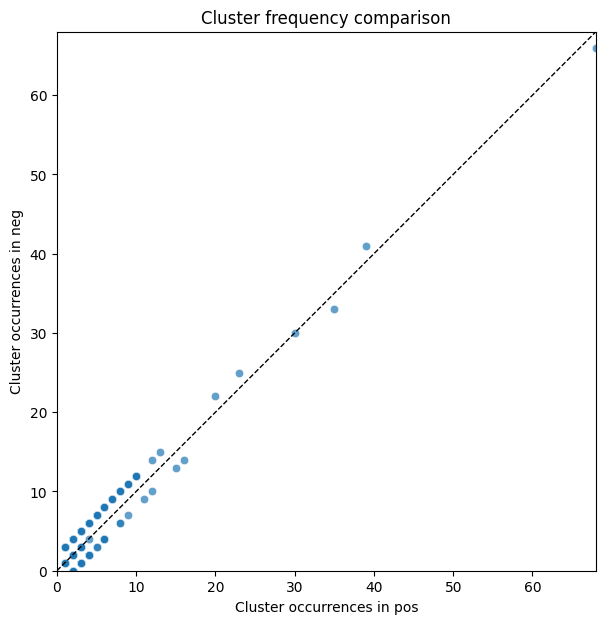

In [55]:
# Sequence degree
def plot_sequence_degree(pos, neg):
    def count_clusters(df, col="new_cluster_pair"):
        return (
            df[col]
            .dropna()
            .astype(str)
            .str.split(",")
            .explode()
            .str.strip()
            .loc[lambda s: s.ne("")]
            .value_counts()
        )

    pos_counts = count_clusters(pos).rename("pos_count")
    neg_counts = count_clusters(neg).rename("neg_count")

    cluster_counts = (
        pd.concat([pos_counts, neg_counts], axis=1)
        .fillna(0)
        .astype(int)
        .reset_index()
        .rename(columns={"index": "cluster"})
    )

    fig, ax = plt.subplots(figsize=(7, 7))

    sns.scatterplot(
        data=cluster_counts,
        x="pos_count",
        y="neg_count",
        ax=ax,
        alpha=0.7
    )

    max_count = cluster_counts[["pos_count", "neg_count"]].to_numpy().max()

    ax.plot([0, max_count], [0, max_count], color="black", linestyle="--", linewidth=1)

    ax.set_xlabel("Cluster occurrences in pos")
    ax.set_ylabel("Cluster occurrences in neg")
    ax.set_title("Cluster frequency comparison")
    ax.set_xlim(0, max_count)
    ax.set_ylim(0, max_count)
    ax.set_aspect("equal", adjustable="box")

    plt.show()

plot_sequence_degree(pos, neg)

## Keep Homomers

In [56]:
df = pd.read_csv("/nfs/scratch/pdb_dimers/balanced_interactions_keep_homomers_cd_hit.tsv", sep="\t")

pos = df[df["sample_kind"] == "positive"]
neg = df[df["sample_kind"] == "negative"]

/tmp/ipykernel_2801073/2367634109.py:1: DtypeWarning: Columns (0: pdb_id, 1: experimental_method, 2: download_url, 3: local_filename, 4: partitions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/nfs/scratch/pdb_dimers/balanced_interactions_keep_homomers_cd_hit.tsv", sep="\t")


In [57]:
print(f"Length Positive: {len(pos)}")
print(f"Length Negative: {len(neg)}")

Length Positive: 35139
Length Negative: 35139


In [58]:
# any unknown clusters ?
pairs = pos["new_cluster_pair"].str.split(",",expand=True)
neg_pairs = neg["new_cluster_pair"].str.split(",",expand=True)

pos_set = set(pairs[0]).union(set(pairs[1]))
neg_set = set(neg_pairs[0]).union(set(neg_pairs[1]))

print(len(neg_set.difference(pos_set)))
print(neg_set.difference(pos_set))

0
set()


In [59]:
pos[pos["new_cluster_pair"].isin(neg["new_cluster_pair"])]

,Unnamed: 0.1,Unnamed: 0,assembly_id,pdb_id,assembly_number,entity_pair,uniprot_pair,uniprot_1,uniprot_2,species_pair,...,resolution_best_angstrom,modeled_polymer_monomer_count,experimental_method,oligomeric_count,download_url,local_filename,partitions,split,label,sample_kind


In [60]:
print(f"Homomers positive: {calc_homomers(pos)}")
print(f"Homomers Negative: {calc_homomers(neg)}")

Homomers positive: 28541
Homomers Negative: 10962


In [61]:
print(f"Same species pos: {calc_same_species(pos)}")
print(f"Same species neg: {calc_same_species(neg)}")

Same species pos: 33183
Same species neg: 33133


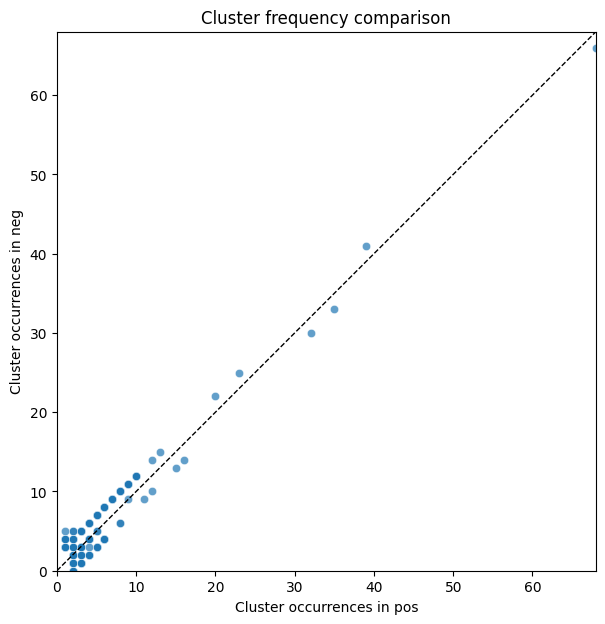

In [62]:
plot_sequence_degree(pos, neg)